# Humpback Whale Identification — ArcFace Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## ArcFace Training

**ArcFace** (Deng et al., CVPR 2019 — course slides 31–33) modifies the classification
head to enforce angular margin between classes on a hypersphere.

Instead of computing logits as `W · f(x)`, ArcFace:
1. L2-normalizes both weight vectors and embeddings
2. Computes cosine similarity (= angular distance on the hypersphere)
3. Adds an angular penalty `m` to the correct class's angle
4. Scales by factor `s` before softmax

This forces the model to cluster same-class embeddings tightly and push different
classes apart by at least `m` radians. The key advantage over triplet loss:
**no pair/triplet mining is needed** — ArcFace works with standard batching (slide 31).

We initialize from the baseline's backbone + embedding weights, replacing only
the classifier head with the ArcFace head.


## Setup & Imports

In [ ]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_dataloaders,
 )
from models import build_model
from training import train
from evaluation import evaluate_retrieval
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cpu


## Experiment Configuration

In [2]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="arcface_effnetb5",
    description="ArcFace angular margin loss, initialized from baseline",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="arcface",       # ← ArcFace head instead of linear
    arcface_scale=30.0,        # Logit scale factor
    arcface_margin=0.5,        # Angular margin (radians)

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=2,  # Shorter freeze: backbone is already good from baseline
    freeze_bn=True,
    epochs=20,
    batch_size=12,
    accumulation_steps=2,
    use_amp=True,

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,              # Slightly lower than baseline (fine-tuning, not fresh)
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="arcface_ce",    # Standard CE on the ArcFace-modified logits
    label_smoothing=0.0,       # No label smoothing with ArcFace (margin handles it)
    use_class_weights=False,   # ArcFace margin handles class separation

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="val_known_acc",

    # ── Initialize from baseline ─────────────────────────────────
    # UPDATE THIS PATH to your best baseline checkpoint:
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
)

print("ArcFace config:")
print(config.summary())


ArcFace config:
efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=12×2 | head=arcface(s=30.0,m=0.5)


## Data Preparation

In [ ]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class

Class mapping: 4247 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [4]:
TRAINING_ENABLED = False
EXPERIMENT_ID = "20260403_163615_arcface_effnetb5_6c8d152f"

if TRAINING_ENABLED:
    # manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

Skipping training


## Training Analysis

c:\Users\Sebastian Munthe\Desktop\ml4cv_final\ML4CV\visualization.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


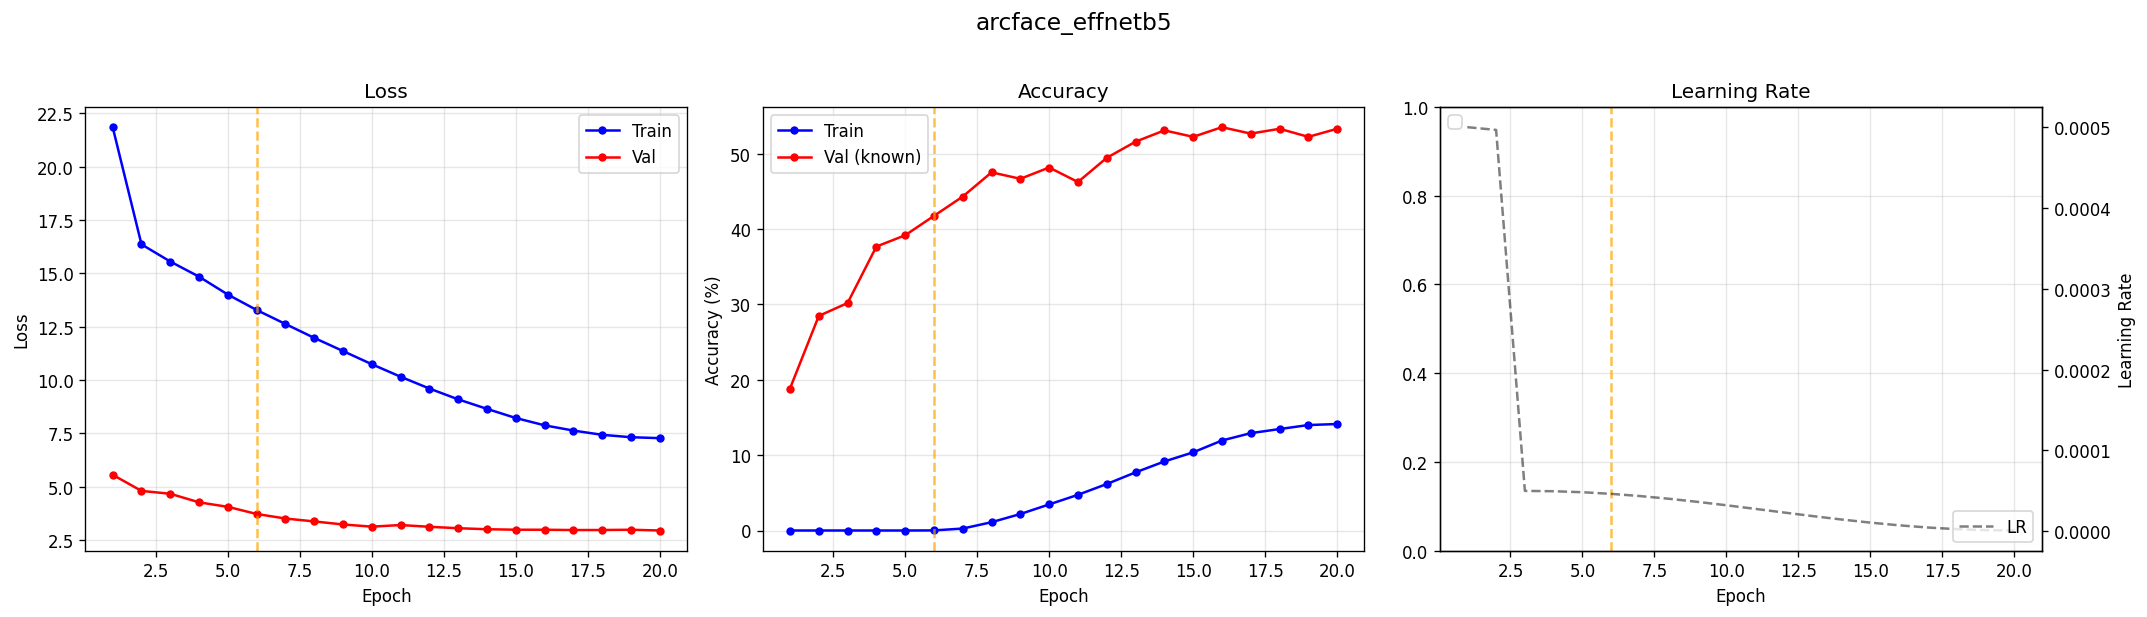

In [6]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [8]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "val_loss", "val_known_acc",
            "val_mean_known_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 7.2737
  val_loss                      : 2.9452
  val_known_acc                 : 53.32%
  val_mean_known_conf           : 0.5060


## Embedding Quality


Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[01:37:13] Loading checkpoint: experiments\20260403_163615_arcface_effnetb5_6c8d152f\checkpoints\best.pth
[01:37:13] Resuming from epoch 16
ArcFace retrieval performance:


  Extracting embeddings:   0%|          | 0/338 [00:07<?, ?it/s]

  Gallery: 8089 embeddings, 4247 identities


  Extracting embeddings:   0%|          | 0/24 [00:06<?, ?it/s]

  Recall@1: 70.66%  Recall@5: 77.73%  NewWhale Det: 0.00%


  Extracting embeddings:   0%|          | 0/24 [00:06<?, ?it/s]

  Extracting embeddings:   0%|          | 0/338 [00:07<?, ?it/s]

t-SNE: 221 points, 10 classes (min 5/class)


C:\Users\krios\AppData\Local\Temp\ipykernel_7404\2588758607.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10" if n_classes <= 10 else "tab20")


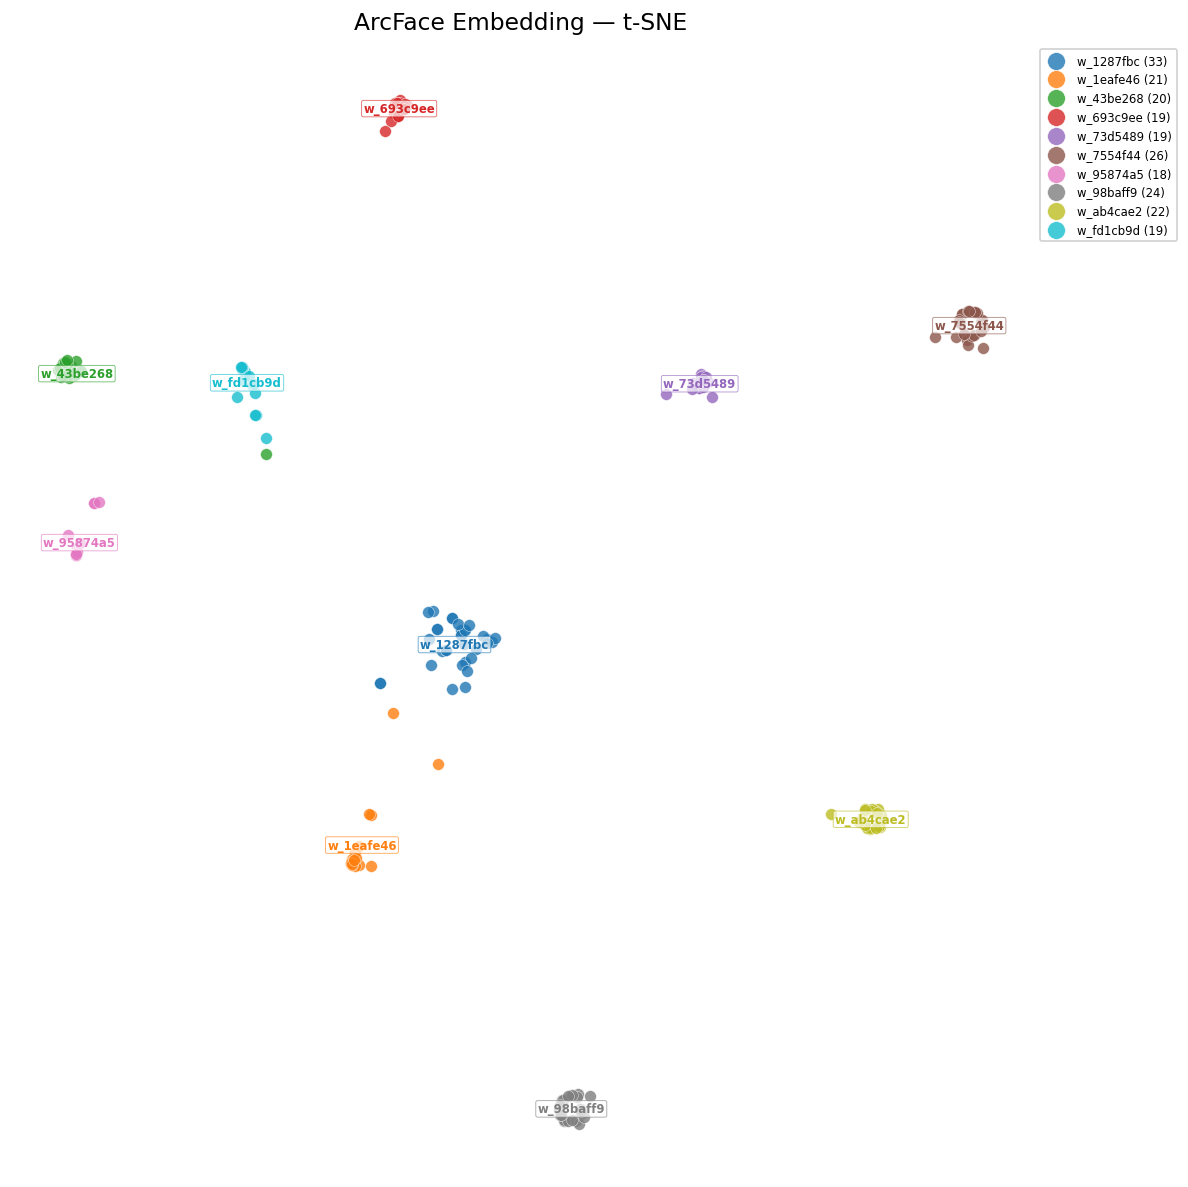

  Perplexity used: 27 | KL divergence: 0.08


In [ ]:
eval_config, data = get_eval_config_and_data()

arcface_model = build_model(config, data["num_classes"], device)
manager.load_checkpoint(arcface_model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

print("ArcFace retrieval performance:")
arcface_retrieval = evaluate_retrieval(
    arcface_model, train_loader, val_loader, eval_config, device,
)

plot_embedding_tsne(arcface_model, val_loader, data, device,
                    title="ArcFace Embedding — t-SNE", combine_loaders=[train_loader])